In [4]:
import pandas as pd
import numpy as np
import math
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
from sklearn.linear_model import Ridge, Lasso
import statsmodels.api as sm
from sklearn.model_selection import train_test_split



import statsmodels.api as sm
from ISLP import load_data
from sklearn.preprocessing import StandardScaler
from ISLP.models import (ModelSpec as MS,
                        summarize,
                        poly)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from functools import partial
from sklearn.model_selection import \
(cross_validate,
KFold,
ShuffleSplit)
from sklearn.base import clone
from ISLP.models import sklearn_sm

In [6]:
os.getcwd()

'C:\\Users\\flori\\OneDrive\\Escritorio\\dataanalytics'

In [7]:
os.chdir("\\Users\\flori\\OneDrive\\Escritorio\\dataanalytics\\Olist")

*Load Data Sets and review their content and columns to answer the docx.*

# Data Set up and cleaning 

We are trying to answer to this question: What factors influence delivery time, and how do they impact it?

The data sets being used are the followings: olist_sellers, olist_orders, olist_order_items, olist_products, olist_customers_dataset

In [118]:
# Load only required columns

olist_sellers = pd.read_csv("olist_sellers_dataset.csv", usecols=[
    "seller_id", "seller_city", "seller_state"])

olist_orders = pd.read_csv("olist_orders_dataset.csv", usecols=[
    "order_id", "customer_id", "order_purchase_timestamp", 
    "order_delivered_customer_date"])

olist_order_items = pd.read_csv("olist_order_items_dataset.csv", usecols=[
    "order_id", "product_id", "freight_value", "seller_id"])

olist_products = pd.read_csv("olist_products_dataset.csv", usecols=[
    "product_id", "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"])

olist_customers = pd.read_csv("olist_customers_dataset.csv", usecols=[
    "customer_id", "customer_state", "customer_city"])

To simplify the analysis of delivery times and logistics, I focused on single-seller orders. This approach allowed for a clearer understanding of delivery performance, without the complexity of multi-seller transactions. Additionally, the number of multi-seller orders was relatively small, so excluding them did not significantly compromise the overall dataset.

In [15]:
# Getting only orders with single seller
filter_orders = olist_order_items.groupby("order_id").agg({"seller_id": "nunique"}).query("seller_id == 1").index
olist_orders = olist_orders[olist_orders["order_id"].isin(filter_orders)]
olist_products["product_volume"] = olist_products["product_length_cm"] * olist_products["product_height_cm"] * olist_products["product_width_cm"]
olist_products.drop(columns=["product_length_cm", "product_height_cm", "product_width_cm"], inplace=True)

In [17]:
# Merge olist_order_items with olist_products on 'product_id' to add product information
olist_order_items_joined = pd.merge(olist_order_items, olist_products, on="product_id", how="left")
# Aggregate data by 'order_id', calculating the count of products, total freight value, total weight, and total volume per order
olist_item_metadata = olist_order_items_joined.groupby("order_id").agg({"product_id": "count", "freight_value": "sum", "product_weight_g": "sum", "product_volume": "sum"})

In [23]:
# Merge all relevant datasets into one
merged_table = pd.merge(olist_orders, olist_customers, on="customer_id", how="left")

merged_table = pd.merge(merged_table, olist_order_items.drop(columns=["product_id", "freight_value"]), on="order_id", how="left")

merged_table = pd.merge(merged_table, olist_item_metadata, on="order_id", how="left")

merged_table = pd.merge(merged_table, olist_sellers, on="seller_id", how="left")

# Rename columns for clarity
merged_table = merged_table.rename(columns={"product_id": "product_count", "product_weight_g": "order_weight_g", "product_volume": "order_volume"})

merged_table


,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,customer_city,customer_state,seller_id,product_count,freight_value,order_weight_g,order_volume,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,sao paulo,SP,3504c0cb71d7fa48d967e0e4c94d59d9,1,8.72,500.0,1976.0,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45,barreiras,BA,289cdb325fb7e7f891c38608bf9e0962,1,22.76,400.0,4693.0,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-17 18:06:29,vianopolis,GO,4869f7a5dfa277a7dca6462dcf3b52b2,1,19.22,420.0,9576.0,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-12-02 00:28:42,sao goncalo do amarante,RN,66922902710d126a0e7d26b0e3805106,1,27.20,450.0,6000.0,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-16 18:17:02,santo andre,SP,2c9e548be18521d1c43cde1c582c6de8,1,8.72,250.0,11475.0,mogi das cruzes,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109542,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,2018-02-28 17:37:56,praia grande,SP,1f9ab4708f3056ede07124aad39a2554,1,20.10,4950.0,16000.0,tupa,SP
109543,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,2017-09-21 11:24:17,nova vicosa,BA,d50d79cb34e38265a8649c383dcffd48,1,65.02,13300.0,63360.0,sao paulo,SP
109544,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,2018-01-25 23:32:54,japuiba,RJ,a1043bafd471dff536d0c462352beb48,2,81.18,13100.0,16000.0,ilicinea,MG
109545,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,2018-01-25 23:32:54,japuiba,RJ,a1043bafd471dff536d0c462352beb48,2,81.18,13100.0,16000.0,ilicinea,MG


In [45]:
merged_table.columns

Index(['order_id', 'customer_id', 'order_purchase_timestamp',
       'order_delivered_customer_date', 'customer_city', 'customer_state',
       'seller_id', 'product_count', 'freight_value', 'order_weight_g',
       'order_volume', 'seller_city', 'seller_state'],
      dtype='object')

In [34]:
#Counting nas
merged_table.isnull().sum()

order_id                            0
customer_id                         0
order_purchase_timestamp            0
order_delivered_customer_date    2448
customer_city                       0
customer_state                      0
seller_id                           0
product_count                       0
freight_value                       0
order_weight_g                      0
order_volume                        0
seller_city                         0
seller_state                        0
dtype: int64

In [122]:
#dropping nas
merged_cleaned = merged_table.dropna()
merged_cleaned.isnull().sum()

order_id                         0
customer_id                      0
order_purchase_timestamp         0
order_delivered_customer_date    0
customer_city                    0
customer_state                   0
seller_id                        0
product_count                    0
freight_value                    0
order_weight_g                   0
order_volume                     0
seller_city                      0
seller_state                     0
dtype: int64

In [525]:
# Sort the data by delivery_time in descending order
top_5_max_delivery_times = merged_cleaned[['delivery_time']].sort_values(by='delivery_time', ascending=False).head(5)

# Display the top 5 maximum delivery times
print(top_5_max_delivery_times)


       delivery_time
21559     209.628611
61193     208.351759
67745     195.634016
77408     194.850174
98101     194.633611


In [134]:
# Ensure that the columns are correctly converted to datetime before calculation
merged_cleaned['order_delivered_customer_date'] = merged_cleaned.loc[:, 'order_delivered_customer_date'] = pd.to_datetime(
    merged_cleaned['order_delivered_customer_date'], errors='coerce')
merged_cleaned['order_purchase_timestamp'] = merged_cleaned.loc[:, 'order_purchase_timestamp'] = pd.to_datetime(
    merged_cleaned['order_purchase_timestamp'], errors='coerce')

C:\Users\flori\AppData\Local\Temp\ipykernel_2604\3225312666.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_cleaned['order_delivered_customer_date'] = merged_cleaned.loc[:, 'order_delivered_customer_date'] = pd.to_datetime(
C:\Users\flori\AppData\Local\Temp\ipykernel_2604\3225312666.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_cleaned['order_purchase_timestamp'] = merged_cleaned.loc[:, 'order_purchase_timestamp'] = pd.to_datetime(


In [132]:
# Now, creating a new column with the delivery time in days
merged_cleaned.loc[:, 'delivery_time'] = (
    merged_cleaned['order_delivered_customer_date'] - 
    merged_cleaned['order_purchase_timestamp']).apply(lambda x: x.total_seconds()) / (3600 * 24)  # Convert seconds to days
#with log
merged_cleaned.loc[:, 'log_delivery_time'] = np.log(merged_cleaned['delivery_time'])
merged_cleaned.head(2)


,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,customer_city,customer_state,seller_id,product_count,freight_value,order_weight_g,order_volume,seller_city,seller_state,delivery_time,log_delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,sao paulo,SP,3504c0cb71d7fa48d967e0e4c94d59d9,1,8.72,500.0,1976.0,maua,SP,8.436574,2.132576
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45,barreiras,BA,289cdb325fb7e7f891c38608bf9e0962,1,22.76,400.0,4693.0,belo horizonte,SP,13.782037,2.623366


In [136]:
merged_cleaned.describe()

,order_purchase_timestamp,order_delivered_customer_date,product_count,freight_value,order_weight_g,order_volume,delivery_time,log_delivery_time
count,107099,107099,107099.000000,107099.000000,107099.00000,1.070990e+05,107099.000000,107099.000000
mean,2018-01-01 02:36:06.769213696,2018-01-13 16:18:09.056770048,1.354476,26.515644,2839.52571,2.085754e+04,12.570860,2.308454
min,2016-09-15 12:16:38,2016-10-11 13:46:32,1.000000,0.000000,0.00000,0.000000e+00,0.533414,-0.628457
25%,2017-09-13 23:02:52,2017-09-25 21:21:42.500000,1.000000,14.130000,335.00000,3.136000e+03,6.801007,1.917071
50%,2018-01-19 22:17:22,2018-02-02 02:31:50,1.000000,17.950000,825.00000,8.000000e+03,10.255463,2.327811
75%,2018-05-04 15:56:13,2018-05-15 15:56:44.500000,1.000000,27.880000,2400.00000,2.187500e+04,15.734051,2.755827
max,2018-08-29 15:00:37,2018-10-17 13:22:46,21.000000,1794.960000,184400.00000,1.476000e+06,209.628611,5.345337
std,NaN,NaN,1.078484,32.573935,6696.89781,4.351205e+04,9.515412,0.678999


In [67]:
#Making sure we have the desired data type
merged_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 107099 entries, 0 to 109546
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       107099 non-null  object        
 1   customer_id                    107099 non-null  object        
 2   order_purchase_timestamp       107099 non-null  datetime64[ns]
 3   order_delivered_customer_date  107099 non-null  datetime64[ns]
 4   customer_city                  107099 non-null  object        
 5   customer_state                 107099 non-null  object        
 6   seller_id                      107099 non-null  object        
 7   product_count                  107099 non-null  int64         
 8   freight_value                  107099 non-null  float64       
 9   order_weight_g                 107099 non-null  float64       
 10  order_volume                   107099 non-null  float64       
 11  selle

In [69]:
# Initialize the scaler
scaler = StandardScaler()

# Apply scaling to continuous columns
# Use .loc[] to modify the original DataFrame
merged_cleaned.loc[:, ['freight_value', 'order_weight_g', 'order_volume']] = scaler.fit_transform(merged_cleaned[['freight_value', 'order_weight_g', 'order_volume']])


In [71]:
print(merged_cleaned.columns)


Index(['order_id', 'customer_id', 'order_purchase_timestamp',
       'order_delivered_customer_date', 'customer_city', 'customer_state',
       'seller_id', 'product_count', 'freight_value', 'order_weight_g',
       'order_volume', 'seller_city', 'seller_state', 'delivery_time',
       'log_delivery_time'],
      dtype='object')


In [73]:
merged_cleaned.shape

(107099, 15)

In [75]:
merged_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 107099 entries, 0 to 109546
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       107099 non-null  object        
 1   customer_id                    107099 non-null  object        
 2   order_purchase_timestamp       107099 non-null  datetime64[ns]
 3   order_delivered_customer_date  107099 non-null  datetime64[ns]
 4   customer_city                  107099 non-null  object        
 5   customer_state                 107099 non-null  object        
 6   seller_id                      107099 non-null  object        
 7   product_count                  107099 non-null  int64         
 8   freight_value                  107099 non-null  float64       
 9   order_weight_g                 107099 non-null  float64       
 10  order_volume                   107099 non-null  float64       
 11  selle

In [189]:
merged_cleaned.groupby('order_month')['product_count'].sum()

order_month
1     12020
2     12965
3     14339
4     13537
5     15475
6     13533
7     14761
8     15099
9      6319
10     7486
11    11616
12     7913
Name: product_count, dtype: int64

In [191]:
merged_cleaned.groupby('order_month')['product_count'].mean()

order_month
1     1.381927
2     1.404507
3     1.343484
4     1.348172
5     1.348584
6     1.327676
7     1.343008
8     1.311246
9     1.361560
10    1.400299
11    1.409367
12    1.307286
Name: product_count, dtype: float64

In [153]:
numeric_cols = merged_cleaned.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
numeric_cols.corr()


,product_count,freight_value,order_weight_g,order_volume,delivery_time,log_delivery_time
product_count,1.000000,0.557162,0.322829,0.400036,-0.005653,0.004194
freight_value,0.557162,1.000000,0.665104,0.695754,0.134735,0.167787
order_weight_g,0.322829,0.665104,1.000000,0.865051,0.075287,0.082611
order_volume,0.400036,0.695754,0.865051,1.000000,0.069216,0.076799
delivery_time,-0.005653,0.134735,0.075287,0.069216,1.000000,0.860776
log_delivery_time,0.004194,0.167787,0.082611,0.076799,0.860776,1.000000


In [155]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

#VIF TO RECOGNIZE IF WE HAVE ANY MULTICOLLINEARITY
# Select numeric predictors for VIF calculation
X = merged_cleaned[['freight_value', 'order_weight_g', 'order_volume', "product_count"]]  # Add more numeric predictors as needed

# Add a constant for the intercept
X = add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


          Feature       VIF
0           const  2.617470
1   freight_value  2.479463
2  order_weight_g  4.181394
3    order_volume  4.494584
4   product_count  1.479802


In [159]:
# Extract day of the week, month, and hour from the 'order_purchase_timestamp'
merged_cleaned.loc[:, 'order_day_of_week'] = merged_cleaned['order_purchase_timestamp'].apply(lambda x: x.dayofweek)
merged_cleaned.loc[:, 'order_month'] = merged_cleaned['order_purchase_timestamp'].apply(lambda x: x.month)
merged_cleaned.loc[:, 'order_hour'] = merged_cleaned['order_purchase_timestamp'].apply(lambda x: x.hour)


In [161]:

smf.ols("log_delivery_time ~ freight_value + product_count + order_weight_g + order_volume + customer_state + seller_state + C(order_day_of_week) + C(order_month)", data=merged_cleaned).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      log_delivery_time   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     750.5
Date:                Mon, 02 Dec 2024   Prob (F-statistic):               0.00
Time:                        00:13:40   Log-Likelihood:                -89626.
No. Observations:              107099   AIC:                         1.794e+05
Df Residuals:                  107030   BIC:                         1.801e+05
Df Model:                          68                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     3.6466      0.328     11.108      0.000       3.003       4.290
customer_state[T.AL]          0.1559      0.065      2.412      0.016       0.029       0.283
customer_state[T.AM]          0.2323      0.073      3.175      0.001       0.089       0.376
customer_state[T.AP]          0.2244      0.085      2.627      0.009       0.057       0.392
customer_state[T.BA]         -0.0828      0.059     -1.394      0.163      -0.199       0.034
customer_state[T.CE]          0.0018      0.061      0.030      0.976      -0.117       0.120
customer_state[T.DF]         -0.4655      0.060     -7.781      0.000      -0.583      -0.348
customer_state[T.ES]         -0.2726      0.060     -4.552      0.000      -0.390      -0.155
customer_state[T.GO]         -0.2755      0.060     -4.601      0.000      -0.393      -0.158
customer_state[T.MA]          0.0316      0.062      0.510      0.610      -0.090       0.153
customer_state[T.MG]         -0.5588      0.059     -9.489      0.000      -0.674      -0.443
customer_state[T.MS]         -0.2653      0.062     -4.284      0.000      -0.387      -0.144
customer_state[T.MT]         -0.1120      0.061     -1.828      0.068      -0.232       0.008
customer_state[T.PA]          0.1171      0.061      1.914      0.056      -0.003       0.237
customer_state[T.PB]         -0.0472      0.063     -0.748      0.454      -0.171       0.076
customer_state[T.PE]         -0.1376      0.060     -2.287      0.022      -0.256      -0.020
customer_state[T.PI]         -0.1164      0.064     -1.832      0.067      -0.241       0.008
customer_state[T.PR]         -0.5640      0.059     -9.532      0.000      -0.680      -0.448
customer_state[T.RJ]         -0.3934      0.059     -6.681      0.000      -0.509      -0.278
customer_state[T.RN]         -0.0985      0.064     -1.546      0.122      -0.223       0.026
customer_state[T.RO]         -0.0196      0.068     -0.288      0.773      -0.153       0.113
customer_state[T.RR]          0.1626      0.101      1.607      0.108      -0.036       0.361
customer_state[T.RS]         -0.3158      0.059     -5.340      0.000      -0.432      -0.200
customer_state[T.SC]         -0.3492      0.059     -5.884      0.000      -0.466      -0.233
customer_state[T.SE]         -0.0184      0.065     -0.281      0.779      -0.147       0.110
customer_state[T.SP]         -0.9173      0.059    -15.610      0.000      -1.033      -0.802
customer_state[T.TO]         -0.1325      0.067     -1.976      0.048      -0.264      -0.001
seller_state[T.BA]           -0.6787      0.324     -2.097      0.036      -1.313      -0.044
seller_state[T.CE]           -0.5907      0.328     -1.799      0.072      -1.234       0.053
seller_state[T.DF]           -0.6743      0.323     -2.085      0.037      

# Model without outliers

In [183]:
#Analising outlier
extreme_deliveries = merged_cleaned[merged_cleaned['delivery_time'] > 25]  # Adjust the threshold as needed
print(extreme_deliveries[['order_weight_g', 'freight_value', 'order_volume', 'delivery_time']])


        order_weight_g  freight_value  order_volume  delivery_time
26               500.0          15.53        4224.0      28.928484
29               850.0          33.24        8000.0      30.401898
35               850.0          28.95       36000.0      30.374757
41             14300.0          17.12       43928.0      33.896933
108             1500.0          17.84       23625.0      36.340718
...                ...            ...           ...            ...
109441           600.0          35.71        4913.0      25.287685
109473          8350.0          23.91       51300.0      25.965093
109521          1563.0          15.54        5440.0      26.282569
109527           150.0          11.85        1232.0      39.842222
109536           300.0          15.14        1152.0      37.244826

[8588 rows x 4 columns]


In [165]:
# Filter out rows where 'delivery_time' is greater than 50 (outliers)
filtered_data = merged_cleaned[merged_cleaned['delivery_time'] <= 50]

# Check the number of remaining rows
print(f"Rows after removing outliers: {filtered_data.shape[0]}")


Rows after removing outliers: 106367


In [173]:
filtered_data.isnull().sum()

order_id                         0
customer_id                      0
order_purchase_timestamp         0
order_delivered_customer_date    0
customer_city                    0
customer_state                   0
seller_id                        0
product_count                    0
freight_value                    0
order_weight_g                   0
order_volume                     0
seller_city                      0
seller_state                     0
delivery_time                    0
log_delivery_time                0
order_day_of_week                0
order_month                      0
order_hour                       0
dtype: int64

In [177]:
filtered_data.select_dtypes(include=['float64', 'int64']).describe()

,product_count,freight_value,order_weight_g,order_volume,delivery_time,log_delivery_time,order_day_of_week,order_month,order_hour
count,106367.000000,106367.000000,106367.000000,1.063670e+05,106367.000000,106367.000000,106367.000000,106367.000000,106367.000000
mean,1.355279,26.467096,2829.776190,2.080693e+04,12.182554,2.295583,2.739835,6.033591,14.756795
std,1.080708,32.565429,6682.070753,4.341388e+04,7.969051,0.662835,1.960522,3.230252,5.305686
min,1.000000,0.000000,0.000000,0.000000e+00,0.533414,-0.628457,0.000000,1.000000,0.000000
25%,1.000000,14.110000,334.000000,3.136000e+03,6.773044,1.912951,1.000000,3.000000,11.000000
50%,1.000000,17.940000,820.000000,8.000000e+03,10.206470,2.323022,3.000000,6.000000,15.000000
75%,1.000000,27.795000,2400.000000,2.186150e+04,15.487182,2.740013,4.000000,8.000000,19.000000
max,21.000000,1794.960000,184400.000000,1.476000e+06,49.990278,3.911829,6.000000,12.000000,23.000000


In [169]:
# Model without outliers
ols_model_filtered = smf.ols(
    "log_delivery_time ~ freight_value + product_count + order_weight_g + order_volume + "
    "customer_state + seller_state + C(order_day_of_week) + C(order_month)",
    data=filtered_data
).fit()

# Print the summary of the model without the outliers
print(ols_model_filtered.summary())

                            OLS Regression Results                            
Dep. Variable:      log_delivery_time   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     745.3
Date:                Mon, 02 Dec 2024   Prob (F-statistic):               0.00
Time:                        00:13:51   Log-Likelihood:                -86452.
No. Observations:              106367   AIC:                         1.730e+05
Df Residuals:                  106298   BIC:                         1.737e+05
Df Model:                          68                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

# Delivery analysis

In [515]:
ols_model = smf.ols("log_delivery_time ~ freight_value + product_count + order_weight_g + order_volume + customer_state + seller_state + C(order_day_of_week) + C(order_month) + holiday_period", data=merged_cleaned).fit()

# Display the summary of the OLS regression
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      log_delivery_time   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     739.7
Date:                Thu, 28 Nov 2024   Prob (F-statistic):               0.00
Time:                        23:49:54   Log-Likelihood:                -89624.
No. Observations:              107099   AIC:                         1.794e+05
Df Residuals:                  107029   BIC:                         1.801e+05
Df Model:                          69                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         3.7240      0.329     11.334      0.000       3.080       4.368
customer_state[T.AL]              0.1558      0.065      2.411      0.016       0.029       0.283
customer_state[T.AM]              0.2324      0.073      3.176      0.001       0.089       0.376
customer_state[T.AP]              0.2248      0.085      2.632      0.008       0.057       0.392
customer_state[T.BA]             -0.0826      0.059     -1.390      0.164      -0.199       0.034
customer_state[T.CE]              0.0021      0.061      0.034      0.972      -0.117       0.121
customer_state[T.DF]             -0.4653      0.060     -7.779      0.000      -0.583      -0.348
customer_state[T.ES]             -0.2723      0.060     -4.546      0.000      -0.390      -0.155
customer_state[T.GO]             -0.2752      0.060     -4.597      0.000      -0.393      -0.158
customer_state[T.MA]              0.0318      0.062      0.514      0.607      -0.090       0.153
customer_state[T.MG]             -0.5586      0.059     -9.485      0.000      -0.674      -0.443
customer_state[T.MS]             -0.2651      0.062     -4.281      0.000      -0.386      -0.144
customer_state[T.MT]             -0.1117      0.061     -1.824      0.068      -0.232       0.008
customer_state[T.PA]              0.1174      0.061      1.919      0.055      -0.003       0.237
customer_state[T.PB]             -0.0471      0.063     -0.747      0.455      -0.171       0.076
customer_state[T.PE]             -0.1373      0.060     -2.282      0.023      -0.255      -0.019
customer_state[T.PI]             -0.1161      0.064     -1.827      0.068      -0.241       0.008
customer_state[T.PR]             -0.5637      0.059     -9.528      0.000      -0.680      -0.448
customer_state[T.RJ]             -0.3931      0.059     -6.677      0.000      -0.508      -0.278
customer_state[T.RN]             -0.0982      0.064     -1.542      0.123      -0.223       0.027
customer_state[T.RO]             -0.0191      0.068     -0.281      0.779      -0.152       0.114
customer_state[T.RR]              0.1632      0.101      1.613      0.107      -0.035       0.361
customer_state[T.RS]             -0.3155      0.059     -5.337      0.000      -0.431      -0.200
customer_state[T.SC]             -0.3490      0.059     -5.881      0.000      -0.465      -0.233
customer_state[T.SE]             -0.0181      0.065     -0.277      0.782      -0.146       0.110
customer_state[T.SP]             -0.9171      0.059    -15.606      0.000      -1.032      -0.802
customer_state[T.TO]             -0.1325      0.067     -1.974      0.048      -0.264      -0.001
seller_state[T.BA]               -0.6793      0.324     -2.099      0.036      -1.314      -0.045
seller_state[T.CE]               -0.5916     

In [544]:
numeric_cols = merged_cleaned.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
numeric_cols.corr()


,product_count,freight_value,order_weight_g,order_volume,delivery_time,log_delivery_time,order_day_of_week,order_month,order_hour
product_count,1.000000,0.557162,0.322829,0.400036,-0.005653,0.004194,-0.021099,-0.005325,-0.012412
freight_value,0.557162,1.000000,0.665104,0.695754,0.134735,0.167787,-0.017212,0.001252,-0.004693
order_weight_g,0.322829,0.665104,1.000000,0.865051,0.075287,0.082611,-0.017517,-0.008985,0.005780
order_volume,0.400036,0.695754,0.865051,1.000000,0.069216,0.076799,-0.020821,-0.000423,0.002244
delivery_time,-0.005653,0.134735,0.075287,0.069216,1.000000,0.860776,0.029903,-0.056419,0.002625
log_delivery_time,0.004194,0.167787,0.082611,0.076799,0.860776,1.000000,0.053962,-0.049136,0.005879
order_day_of_week,-0.021099,-0.017212,-0.017517,-0.020821,0.029903,0.053962,1.000000,0.022705,0.009672
order_month,-0.005325,0.001252,-0.008985,-0.000423,-0.056419,-0.049136,0.022705,1.000000,-0.005036
order_hour,-0.012412,-0.004693,0.005780,0.002244,0.002625,0.005879,0.009672,-0.005036,1.000000


In [594]:
# Select numerical columns that are relevant to delivery time analysis
numeric_cols = merged_cleaned[['delivery_time', 'freight_value', 'order_weight_g', 'product_count', 'order_volume', 'order_month']]

# Compute the correlation matrix
corr_matrix = numeric_cols.corr()

# Display the correlation matrix
print(corr_matrix)


                delivery_time  freight_value  order_weight_g  product_count  \
delivery_time        1.000000       0.134735        0.075287      -0.005653   
freight_value        0.134735       1.000000        0.665104       0.557162   
order_weight_g       0.075287       0.665104        1.000000       0.322829   
product_count       -0.005653       0.557162        0.322829       1.000000   
order_volume         0.069216       0.695754        0.865051       0.400036   
order_month         -0.056419       0.001252       -0.008985      -0.005325   

                order_volume  order_month  
delivery_time       0.069216    -0.056419  
freight_value       0.695754     0.001252  
order_weight_g      0.865051    -0.008985  
product_count       0.400036    -0.005325  
order_volume        1.000000    -0.000423  
order_month        -0.000423     1.000000  


In [607]:
# Make sure 'seller_encoded' and 'city_encoded' are in your numeric columns
numeric_cols = merged_cleaned.select_dtypes(include=['float64', 'int64'])

# If you have 'seller_encoded' and 'city_encoded' columns, add them manually to the numeric_cols
numeric_cols = numeric_cols.assign(
    seller_encoded=merged_cleaned['seller_encoded'],
    city_encoded=merged_cleaned['city_encoded']
)

# Recalculate the correlation matrix
correlation_matrix = numeric_cols.corr()

# Display the updated correlation matrix
print(correlation_matrix)


                   product_count  freight_value  order_weight_g  order_volume  \
product_count           1.000000       0.557162        0.322829      0.400036   
freight_value           0.557162       1.000000        0.665104      0.695754   
order_weight_g          0.322829       0.665104        1.000000      0.865051   
order_volume            0.400036       0.695754        0.865051      1.000000   
delivery_time          -0.005653       0.134735        0.075287      0.069216   
log_delivery_time       0.004194       0.167787        0.082611      0.076799   
order_day_of_week      -0.021099      -0.017212       -0.017517     -0.020821   
order_month            -0.005325       0.001252       -0.008985     -0.000423   
order_hour             -0.012412      -0.004693        0.005780      0.002244   
seller_encoded         -0.037146      -0.041668       -0.047517     -0.062850   
city_encoded            0.008107      -0.052709       -0.003382     -0.004843   

                   delivery

In [554]:
merged_cleaned.loc[:, 'holiday_numeric'] = merged_cleaned['holiday_period'].apply(lambda x: 1 if x == 'Holiday' else 0)


In [556]:
holiday_correlation = merged_cleaned['holiday_numeric'].corr(merged_cleaned['delivery_time'])
print(f"Correlation between holiday_period and delivery_time: {holiday_correlation}")
'''
Here i found out that my estimates on holiday, barely have influence in the delivery time

Correlation between holiday_period and delivery_time: 0.014204058756924473


In [193]:
# Boxplot for delivery time by holiday_period
plt.figure(figsize=(8, 6))
sns.boxplot(data=merged_cleaned, x='holiday_period', y='delivery_time', palette='Set2')
plt.title('Delivery Time Distribution by Holiday Period')
plt.ylabel('Delivery Time (days)')
plt.xlabel('Holiday Period')
plt.show()


ValueError: Could not interpret value `holiday_period` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

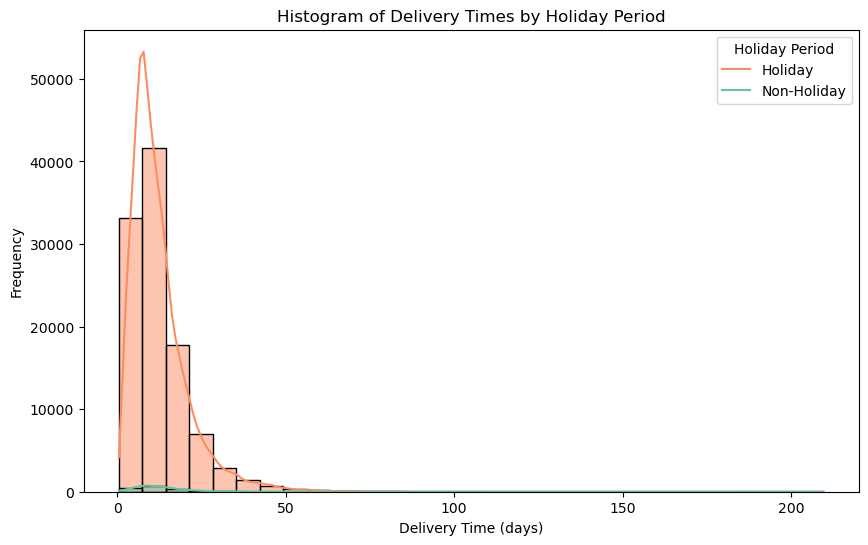

In [566]:
# Histogram for delivery times split by holiday_period
plt.figure(figsize=(10, 6))
sns.histplot(data=merged_cleaned, x='delivery_time', hue='holiday_period', kde=True, bins=30, palette='Set2')
plt.title('Histogram of Delivery Times by Holiday Period')
plt.xlabel('Delivery Time (days)')
plt.ylabel('Frequency')
plt.legend(title='Holiday Period', labels=['Holiday', 'Non-Holiday'])
plt.show()


In [171]:
# Average delivery time comparison
mean_delivery_time = merged_cleaned.groupby('holiday_period')['delivery_time'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=mean_delivery_time, x='holiday_period', y='delivery_time', palette='Set2')
plt.title('Average Delivery Time by Holiday Period')
plt.ylabel('Average Delivery Time (days)')
plt.xlabel('Holiday Period')
plt.show()


KeyError: 'holiday_period'

                  mean     median  count
order_month                             
1            14.033201  11.497633   8698
2            16.235953  13.624433   9231
3            15.308929  12.195903  10673
4            12.304239  10.182222  10041
5            11.439883   9.479653  11475
6            10.134430   8.788854  10193
7             9.966951   8.304248  10991
8             9.086566   7.865567  11515
9            11.940156  10.444850   4641
10           12.301531  10.368356   5346
11           15.153722  12.800949   8242
12           15.302477  13.124653   6053


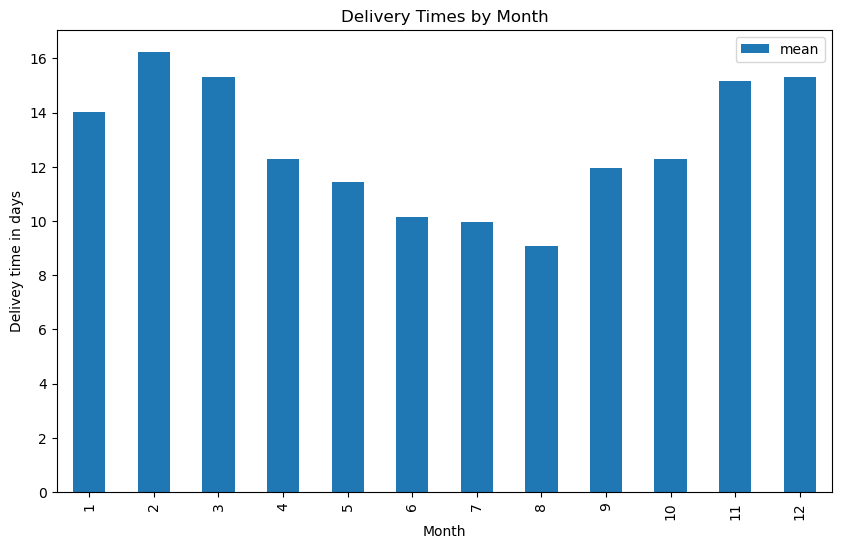

In [592]:
# Group by month and compute statistics
monthly_stats = merged_cleaned.groupby('order_month')['delivery_time'].agg(['mean', 'median', 'count'])
print(monthly_stats)

# Optional plot
monthly_stats[['mean']].plot(kind='bar', figsize=(10, 6))
plt.title('Delivery Times by Month')
plt.xlabel('Month')
plt.ylabel('Delivey time in days')
plt.show()


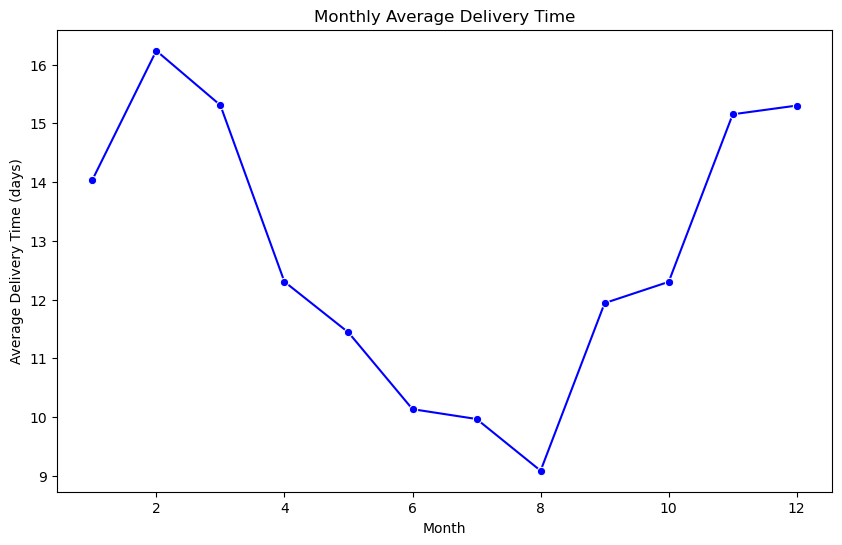

In [570]:
monthly_avg_delivery = merged_cleaned.groupby('order_month')['delivery_time'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_avg_delivery, x='order_month', y='delivery_time', marker='o', color='blue')
plt.title('Monthly Average Delivery Time')
plt.xlabel('Month')
plt.ylabel('Average Delivery Time (days)')
plt.show()


C:\Users\flori\AppData\Local\Temp\ipykernel_1964\2446187621.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_order_count, x='order_month', y='order_id', palette='Set2')


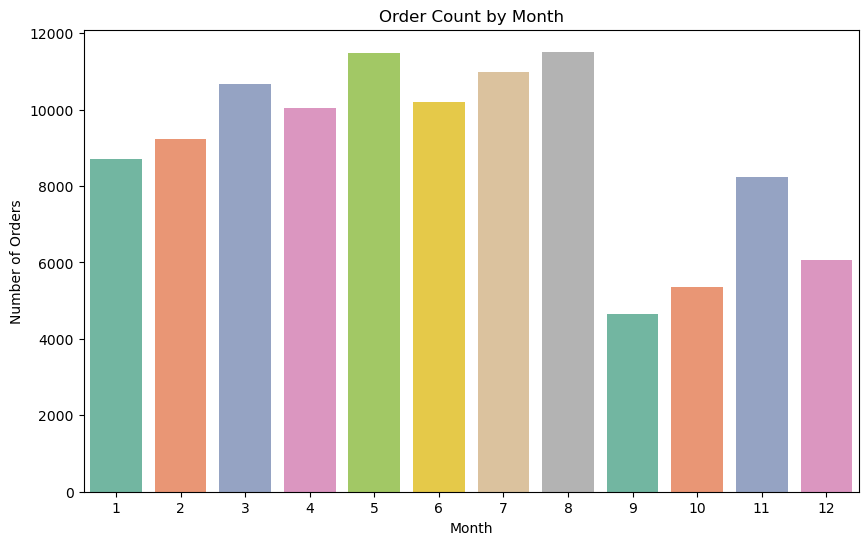

In [574]:
monthly_order_count = merged_cleaned.groupby('order_month')['order_id'].count().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_order_count, x='order_month', y='order_id', palette='Set2')
plt.title('Order Count by Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.show()


In [195]:
# Step 1: Count orders by month
monthly_order_count = merged_cleaned.groupby('order_month')['order_id'].count().reset_index()

# Step 2: Calculate the mean number of orders per month
mean_orders_per_month = monthly_order_count['order_id'].mean()

# Output the mean
print(f"The mean number of orders per month is: {mean_orders_per_month:.2f}")


The mean number of orders per month is: 8924.92


C:\Users\flori\AppData\Local\Temp\ipykernel_1964\1700461922.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_avg_delivery, x='order_month', y='delta', palette='coolwarm')


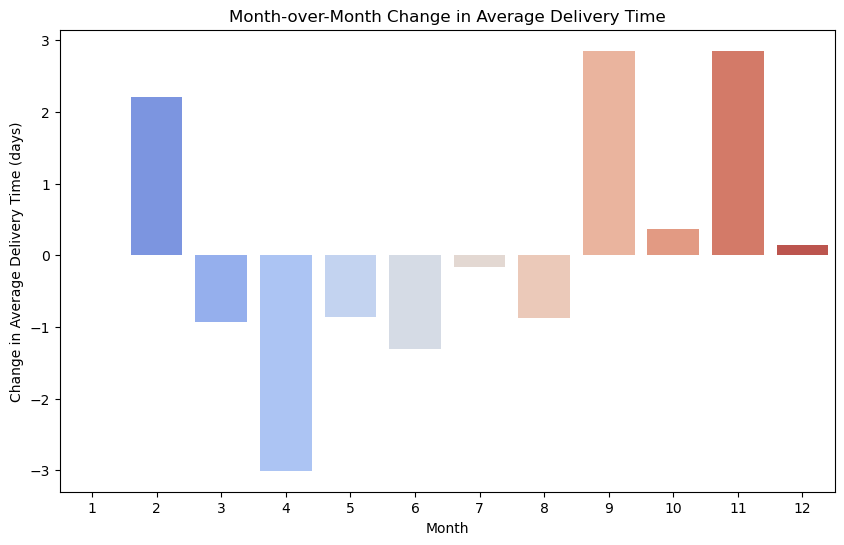

In [580]:
monthly_avg_delivery['delta'] = monthly_avg_delivery['delivery_time'].diff()

plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_avg_delivery, x='order_month', y='delta', palette='coolwarm')
plt.title('Month-over-Month Change in Average Delivery Time')
plt.xlabel('Month')
plt.ylabel('Change in Average Delivery Time (days)')
plt.show()


In [ ]:
'''
with this table we can confirm that the last months sep - january are the months with less orders and at the same time with the slowest distribution, when there are more orders, the delivery is faster.

In [590]:
extreme_deliveries = merged_cleaned[merged_cleaned['delivery_time'] > 50]  # Adjust the threshold as needed
print(extreme_deliveries[['order_weight_g', 'freight_value', 'order_volume', 'delivery_time']])


        order_weight_g  freight_value  order_volume  delivery_time
121          -0.349346      -0.381154     -0.302850      56.026481
127          -0.129094      -0.027803     -0.099618      54.828194
278          -0.140293      -0.069247      0.041884      81.334722
483          -0.364279      -0.253444     -0.388343      59.040023
726          -0.386677      -0.272785     -0.458876      75.683403
...                ...            ...           ...            ...
108178        0.188219      -0.102403     -0.060157     104.793310
108693       -0.162692       0.352564     -0.267549      55.456053
108736        1.561995       0.731397      0.976802      68.221331
108774       -0.416542      -0.244235     -0.410406      56.745532
109184       -0.334414      -0.315150     -0.387424      58.723438

[732 rows x 4 columns]


In [537]:
# Sampling 10000 random rows from the dataset to investigate
sample_data = merged_cleaned.sample(n=10000, random_state=42)


In [266]:
holiday_delivery_stats = merged_cleaned.groupby('holiday_period')['delivery_time'].describe()
print(holiday_delivery_stats)


                   count       mean       std       min       25%        50%  \
holiday_period                                                                 
Holiday           1706.0  13.633178  9.796785  1.723322  7.727543  11.675405   
Non-Holiday     105393.0  12.553664  9.509861  0.533414  6.784988  10.237662   

                      75%         max  
holiday_period                         
Holiday         16.508006  174.048079  
Non-Holiday     15.719537  209.628611  


In [101]:
import pandas as pd

# Ensure 'order_purchase_timestamp' is in datetime format
merged_cleaned.loc[:, 'order_purchase_timestamp'] = pd.to_datetime(merged_cleaned['order_purchase_timestamp'], errors='coerce')

# Define the holiday periods for multiple years (2017-2024)
holiday_years = range(2016, 2019)  # From 2017 to 2024 (or adjust based on your data)

# Create a list of holiday dates for each year
holidays = {
    'New Year': [f'{year}-01-01' for year in holiday_years],
    'Carnival': [f'{year}-02-12' for year in holiday_years],
    'Good Friday': [f'{year}-03-29' for year in holiday_years],
    'Tiradentes Day': [f'{year}-04-21' for year in holiday_years],
    'Labor Day': [f'{year}-05-01' for year in holiday_years],
    'Independence Day': [f'{year}-09-07' for year in holiday_years],
    'Proclamation of the Republic': [f'{year}-11-15' for year in holiday_years],
    'Christmas': [f'{year}-12-25' for year in holiday_years]
}

# Convert holiday dates to datetime format and extract the date part
holiday_dates = pd.to_datetime([date for holiday_list in holidays.values() for date in holiday_list]).date

# Create the 'holiday_period' column by checking if the order's timestamp matches a holiday
merged_cleaned.loc[:, 'holiday_period'] = merged_cleaned['order_purchase_timestamp'].apply(
    lambda x: 'Holiday' if x.date() in holiday_dates else 'Non-Holiday'
)

# Check the value counts again to confirm the holiday period assignment
print(merged_cleaned['holiday_period'].value_counts())

# Optionally, inspect a few rows to verify results
print(merged_cleaned[['order_purchase_timestamp', 'holiday_period']].head(10))
merged_cleaned['holiday_period'


holiday_period
Non-Holiday    105393
Holiday          1706
Name: count, dtype: int64
   order_purchase_timestamp holiday_period
0       2017-10-02 10:56:33    Non-Holiday
1       2018-07-24 20:41:37    Non-Holiday
2       2018-08-08 08:38:49    Non-Holiday
3       2017-11-18 19:28:06    Non-Holiday
4       2018-02-13 21:18:39    Non-Holiday
5       2017-07-09 21:57:05    Non-Holiday
7       2017-05-16 13:10:30    Non-Holiday
8       2017-01-23 18:29:09    Non-Holiday
9       2017-07-29 11:55:02    Non-Holiday
10      2017-05-16 19:41:10    Non-Holiday


In [105]:
import pandas as pd
import numpy as np

# Ensure 'order_purchase_timestamp' is in datetime format
merged_cleaned.loc[:, 'order_purchase_timestamp'] = pd.to_datetime(
    merged_cleaned['order_purchase_timestamp'], errors='coerce'
)

# Define the holiday periods for multiple years (2016-2018)
holiday_years = range(2016, 2019)

# Single-day holidays
single_day_holidays = {
    'New Year': [f'{year}-01-01' for year in holiday_years],
    'Tiradentes Day': [f'{year}-04-21' for year in holiday_years],
    'Labor Day': [f'{year}-05-01' for year in holiday_years],
    'Independence Day': [f'{year}-09-07' for year in holiday_years],
    'Proclamation of the Republic': [f'{year}-11-15' for year in holiday_years],
    'Christmas': [f'{year}-12-25' for year in holiday_years]
}

# Multi-day holidays (define start and end dates)
multi_day_holidays = {
    'Carnival': [pd.date_range(f'{year}-02-11', f'{year}-02-13') for year in holiday_years],
    'Good Friday': [pd.date_range(f'{year}-03-28', f'{year}-03-30') for year in holiday_years]
}

# Flatten both single-day and multi-day holiday dates into one list
all_holidays = [
    pd.to_datetime(date).date()
    for holiday_list in single_day_holidays.values() for date in holiday_list
]

# Properly handle multi-day holidays (flatten and convert to datetime.date)
for holiday_ranges in multi_day_holidays.values():
    for date_range in holiday_ranges:
        all_holidays.extend([date.date() for date in date_range])

# Convert the list to a set for efficient lookup
holiday_dates_set = set(all_holidays)

# Create the 'holiday_period' column by checking if the order's timestamp matches a holiday
merged_cleaned.loc[:, 'holiday_period2'] = merged_cleaned['order_purchase_timestamp'].apply(
    lambda x: 'Holiday' if x.date() in holiday_dates_set else 'Non-Holiday'
)

# Debugging: Check the value counts to confirm the holiday period assignment
print(merged_cleaned['holiday_period2'].value_counts())

# Create a numeric version of the holiday column for regression
merged_cleaned.loc[:, 'holiday_numeric'] = merged_cleaned['holiday_period2'].apply(
    lambda x: 1 if x == 'Holiday' else 0
)

# Debugging: Inspect a few rows to verify the assignments
print(merged_cleaned[['order_purchase_timestamp', 'holiday_period2', 'holiday_numeric']].head(10))


holiday_period2
Non-Holiday    104236
Holiday          2863
Name: count, dtype: int64
   order_purchase_timestamp holiday_period2  holiday_numeric
0       2017-10-02 10:56:33     Non-Holiday                0
1       2018-07-24 20:41:37     Non-Holiday                0
2       2018-08-08 08:38:49     Non-Holiday                0
3       2017-11-18 19:28:06     Non-Holiday                0
4       2018-02-13 21:18:39         Holiday                1
5       2017-07-09 21:57:05     Non-Holiday                0
7       2017-05-16 13:10:30     Non-Holiday                0
8       2017-01-23 18:29:09     Non-Holiday                0
9       2017-07-29 11:55:02     Non-Holiday                0
10      2017-05-16 19:41:10     Non-Holiday                0


C:\Users\flori\AppData\Local\Temp\ipykernel_2604\2433779522.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_cleaned.loc[:, 'holiday_period2'] = merged_cleaned['order_purchase_timestamp'].apply(


In [107]:
import statsmodels.formula.api as smf

# Updated OLS model with holiday_period as a categorical variable
ols_model = smf.ols(
    "log_delivery_time ~ freight_value + product_count + order_weight_g + order_volume + "
    "customer_state + seller_state + C(order_day_of_week) + C(order_month) + C(holiday_period2)",  # C() creates dummy variables
    data=merged_cleaned
).fit()

# Print the summary of the updated regression results
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:      log_delivery_time   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     739.6
Date:                Sun, 01 Dec 2024   Prob (F-statistic):               0.00
Time:                        23:18:51   Log-Likelihood:                -89626.
No. Observations:              107099   AIC:                         1.794e+05
Df Residuals:                  107029   BIC:                         1.801e+05
Df Model:                          69                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [497]:
# Filter only numeric columns from the columns to include
numeric_columns = sampled_data[columns_to_include].select_dtypes(include=['number'])

# Perform aggregation on the numeric columns
sampled_raw_stats = numeric_columns.agg(['min', 'mean', 'max', 'count'])

# Print the results
print("Sampled Data Statistics:")
print(sampled_raw_stats)

# Now for the holiday period stats (filter by 'holiday_period' column)
sampled_holiday_stats = sampled_data[sampled_data['holiday_period'] == 'Holiday'][columns_to_include].select_dtypes(include=['number']).agg(['min', 'mean', 'max', 'count'])

# Print the holiday period statistics
print("\nHoliday Period Statistics:")
print(sampled_holiday_stats)


Sampled Data Statistics:
       freight_value  product_count  order_weight_g  order_volume  \
min        -0.814018       1.000000       -0.424008     -0.479353   
mean        0.005937       1.354715        0.002101      0.009442   
max        29.955819      21.000000       27.111258     33.442444   
count   10710.000000   10710.000000    10710.000000  10710.000000   

       delivery_time  log_delivery_time  
min         0.935984          -0.066157  
mean       12.567669           2.311159  
max       182.658137           5.207616  
count   10710.000000       10710.000000  

Holiday Period Statistics:
       freight_value  product_count  order_weight_g  order_volume  \
min        -0.814018       1.000000       -0.416542     -0.471263   
mean       -0.051161       1.202312        0.095284      0.115246   
max         5.151209       4.000000        4.996437      5.303555   
count     173.000000     173.000000      173.000000    173.000000   

       delivery_time  log_delivery_time  
min

In [113]:

# Updated OLS model with holiday_period included
ols_model = smf.ols(
    "log_delivery_time ~ freight_value + product_count + order_weight_g + order_volume + "
    "customer_state + seller_state + C(order_day_of_week) + C(order_month) + C(holiday_period)",
    data=merged_cleaned
).fit()

# Print the summary of the updated regression results
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:      log_delivery_time   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     739.6
Date:                Sun, 01 Dec 2024   Prob (F-statistic):               0.00
Time:                        23:24:42   Log-Likelihood:                -89626.
No. Observations:              107099   AIC:                         1.794e+05
Df Residuals:                  107029   BIC:                         1.801e+05
Df Model:                          69                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [513]:
# Using .loc[] to avoid the warning
merged_cleaned.loc[:, 'holiday_period'] = merged_cleaned['holiday_period'].astype('category')
merged_cleaned.loc[:, 'holiday_period'] = merged_cleaned['holiday_period'].cat.reorder_categories(['Holiday', 'Non-Holiday'], ordered=True)


# Ridge and lasso in normal model

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Define your target and features
y = merged_cleaned['log_delivery_time']
X = merged_cleaned[['freight_value', 'product_weight_g', 'order_day_of_week', 'order_month', 'order_hour']]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Create an array of alphas for Ridge regression (using a wide range)
alphas = np.logspace(8, -2, 100)

# Fit RidgeCV which automatically tunes alpha with cross-validation
ridge_cv = RidgeCV(alphas=alphas, store_cv_values=True)
ridge_cv.fit(X_train, y_train)

# Best alpha found by cross-validation
print(f"Best alpha: {ridge_cv.alpha_}")

# Test the model on the test set
ridge_score = ridge_cv.score(X_test, y_test)
print(f"Test score: {ridge_score}")


In [ ]:


# Define your target and features
y = merged_cleaned['log_delivery_time']
X = merged_cleaned[['freight_value', 'product_weight_g', 'order_day_of_week', 'order_month', 'order_hour']]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Create an array of alphas for Ridge regression (using a wide range)
alphas = np.logspace(8, -2, 100)

# Manually perform Ridge regression for each alpha to extract coefficients for all alphas
ridge_coefs = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    ridge_coefs.append(ridge.coef_)

# Convert list of coefficients to a numpy array for easier plotting
ridge_coefs = np.array(ridge_coefs)

# Plot the coefficients for each feature as a function of log10(alpha)
plt.figure(figsize=(8, 6))
for i in range(ridge_coefs.shape[1]):  # Loop over each feature
    plt.plot(np.log10(alphas), ridge_coefs[:, i], label=f'Feature {X.columns[i]}')

plt.xlabel('Log10(Alpha)', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.title('Ridge Regression: Coefficients as a Function of Alpha', fontsize=14)
plt.legend()
plt.show()


In [ ]:
# Use the log-transformed delivery time as the target variable
y = merged_cleaned['log_delivery_time']

# Define the independent variables (same as in the OLS model)
X = merged_cleaned[['freight_value', 'product_weight_g', 'order_day_of_week', 'order_month', 'order_hour']]

# Step 1: Scale the features (independent variables)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Create an array of alphas for Lasso regression (regularization strength)
alphas = np.logspace(8, -2, 100)  # Creates a range of values for alpha (lambda)

# Fit Lasso regression for each alpha value and store the results
lasso_coefs = []  # Store the coefficients for each alpha value
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)  # Fit the model with the training data
    lasso_coefs.append(lasso.coef_)

# Convert list of coefficients to a numpy array for easy access
lasso_coefs = np.array(lasso_coefs)

# Plot the coefficients for each alpha (regularization strength)
plt.figure(figsize=(8, 6))

# Plot each feature's coefficient as a function of alpha
for i in range(X_train.shape[1]):
    plt.plot(np.log10(alphas), lasso_coefs[:, i], label=f'{X.columns[i]}')

plt.xlabel('Log10(Alpha)', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.title('Lasso Regression: Coefficients as a Function of Alpha', fontsize=14)
plt.legend()
plt.show()


# kfold

In [21]:
#kfold chatgpt
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
import numpy as np

# Step 1: Prepare the data
X = merged_cleaned[['freight_value', 'product_weight_g', 'order_day_of_week', 'order_month', 'order_hour']]
y = merged_cleaned['log_delivery_time']

# Step 2: Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Set up K-Fold Cross-validation (e.g., 5-fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Step 4: Initialize the Ridge regression model
ridge_model = RidgeCV(alphas=np.logspace(-6, 6, 13), store_cv_values=True)

# Store the results
cv_errors = []

# Step 5: Perform K-Fold Cross-validation
for train_index, val_index in kf.split(X_scaled):
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    # Fit the Ridge model on training data
    ridge_model.fit(X_train, y_train)
    
    # Calculate the Mean Squared Error (MSE) on the validation set
    val_error = np.mean((ridge_model.predict(X_val) - y_val) ** 2)
    cv_errors.append(val_error)

# Step 6: Calculate the average cross-validation error
mean_cv_error = np.mean(cv_errors)
print(f"Mean Cross-Validation Error (MSE): {mean_cv_error}")


NameError: name 'merged_cleaned' is not defined

In [ ]:
for fold, val_error in enumerate(cv_errors, 1):
    print(f"Fold {fold} MSE: {val_error}")


In [23]:
#kfold diana LOG
# Split the dataset into training and test sets (80% train, 20% test)
train_data, test_data = train_test_split(merged_cleaned, test_size=0.2, random_state=0)

# Define the model using the original variables plus log_mpg
hp_model = sklearn_sm(sm.OLS,
                      MS(['freight_value', 'product_weight_g', 'order_day_of_week', 'order_month', 'order_hour']))  # Original variables

# Prepare training data
X_train, Y_train = train_data.drop(columns=['log_delivery_time']), train_data['log_delivery_time']  # Use log_mpg for Y

# Cross-validation on training data
cv_results = cross_validate(hp_model, 
                            X_train, 
                            Y_train,
                            cv=5)  # Use 5-fold cross-validation for example

# Calculate the average cross-validation error
cv_err = np.mean(cv_results['test_score'])
cv_err


NameError: name 'train_test_split' is not defined

In [25]:
#kfold diana LOG
# Split the dataset into training and test sets (80% train, 20% test)
train_data, test_data = train_test_split(merged_cleaned, test_size=0.2, random_state=0)

# Define the model using the original variables plus log_mpg
hp_model = sklearn_sm(sm.OLS,
                      MS(['freight_value', 'product_weight_g', 'order_day_of_week', 'order_month', 'order_hour']))  # Original variables

# Prepare training data
X_train, Y_train = train_data.drop(columns=['delivery_time']), train_data['delivery_time']  # Use log_mpg for Y

# Cross-validation on training data
cv_results = cross_validate(hp_model, 
                            X_train, 
                            Y_train,
                            cv=5)  # Use 5-fold cross-validation for example

# Calculate the average cross-validation error
cv_err = np.mean(cv_results['test_score'])
cv_err


NameError: name 'train_test_split' is not defined